# CLPsych Data Preprocessing Script

This script is used to:
1. Collect statistics and visualize basic dataset information
2. Convert JSON files to CSV format
3. Merge all CSV files and add timeline_id column

In [13]:
# Import necessary libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Part 1: Collect Dataset Statistics

In [14]:
# Set data path
data_dir = Path('./train_tasks12')
json_files = list(data_dir.glob('*.json'))

print(f"Found {len(json_files)} JSON files")

Found 30 JSON files


In [15]:
# Collect statistics
timeline_stats = []

for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        timeline_id = data['timeline_id']
        num_posts = len(data['posts'])
        timeline_stats.append({
            'timeline_id': timeline_id,
            'num_posts': num_posts
        })

# Convert to DataFrame for analysis
stats_df = pd.DataFrame(timeline_stats)

# Calculate statistics
total_timelines = len(stats_df)
total_posts = stats_df['num_posts'].sum()
avg_posts = stats_df['num_posts'].mean()
min_posts = stats_df['num_posts'].min()
max_posts = stats_df['num_posts'].max()
min_timeline = stats_df[stats_df['num_posts'] == min_posts]['timeline_id'].values[0]
max_timeline = stats_df[stats_df['num_posts'] == max_posts]['timeline_id'].values[0]

print("="*60)
print("Dataset Statistics")
print("="*60)
print(f"Number of Timelines: {total_timelines}")
print(f"Total Number of Posts: {total_posts}")
print(f"Average Posts per Timeline: {avg_posts:.2f}")
print(f"Timeline with Minimum Posts: {min_timeline} ({min_posts} posts)")
print(f"Timeline with Maximum Posts: {max_timeline} ({max_posts} posts)")
print("="*60)

Dataset Statistics
Number of Timelines: 30
Total Number of Posts: 373
Average Posts per Timeline: 12.43
Timeline with Minimum Posts: 83997cd4e7 (5 posts)
Timeline with Maximum Posts: 9f2e135af8 (25 posts)


## Part 2: Visualization

Visualization saved as 'dataset_statistics.png'


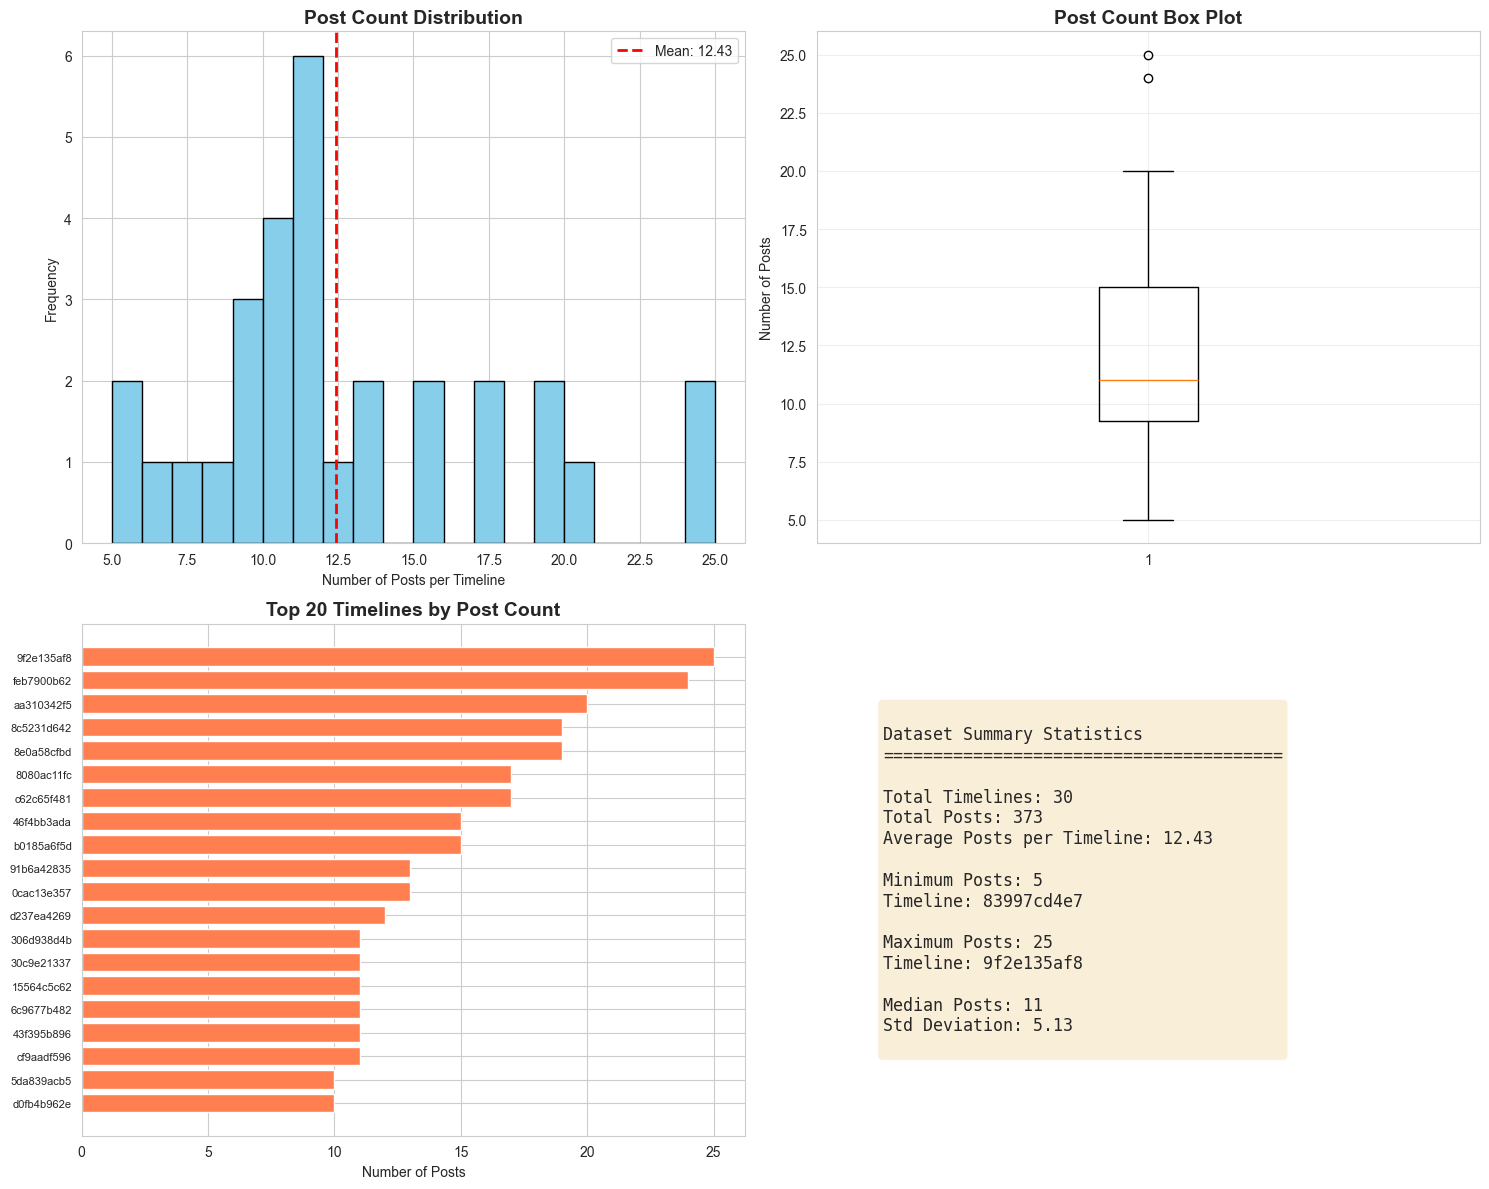

In [16]:
# Create visualization charts
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Chart 1: Post count distribution histogram
axes[0, 0].hist(stats_df['num_posts'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Post Count Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Posts per Timeline')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(avg_posts, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_posts:.2f}')
axes[0, 0].legend()

# Chart 2: Box plot
axes[0, 1].boxplot(stats_df['num_posts'], vert=True)
axes[0, 1].set_title('Post Count Box Plot', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Number of Posts')
axes[0, 1].grid(True, alpha=0.3)

# Chart 3: Top 20 timelines bar chart
top_20 = stats_df.nlargest(20, 'num_posts')
axes[1, 0].barh(range(len(top_20)), top_20['num_posts'], color='coral')
axes[1, 0].set_yticks(range(len(top_20)))
axes[1, 0].set_yticklabels(top_20['timeline_id'], fontsize=8)
axes[1, 0].set_title('Top 20 Timelines by Post Count', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Posts')
axes[1, 0].invert_yaxis()

# Chart 4: Statistical summary text
axes[1, 1].axis('off')
summary_text = f"""
Dataset Summary Statistics
{'='*40}

Total Timelines: {total_timelines}
Total Posts: {total_posts}
Average Posts per Timeline: {avg_posts:.2f}

Minimum Posts: {min_posts}
Timeline: {min_timeline}

Maximum Posts: {max_posts}
Timeline: {max_timeline}

Median Posts: {stats_df['num_posts'].median():.0f}
Std Deviation: {stats_df['num_posts'].std():.2f}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('dataset_statistics.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'dataset_statistics.png'")
plt.show()

## Part 3: Convert JSON to CSV

In [17]:
# Create output directory
csv_output_dir = Path('./csv_files')
csv_output_dir.mkdir(exist_ok=True)

def flatten_evidence(evidence_dict, state_type):
    """Flatten evidence dictionary structure"""
    flattened = {}
    state_data = evidence_dict.get(state_type, {})
    
    # Extract Presence value
    if 'Presence' in state_data:
        flattened[f'{state_type}_presence'] = state_data['Presence']
    else:
        flattened[f'{state_type}_presence'] = None
    
    # Extract Category from all dimensions
    for key, value in state_data.items():
        if key != 'Presence' and isinstance(value, dict):
            flattened[f'{state_type}_{key}_category'] = value.get('Category', None)
            flattened[f'{state_type}_{key}_evidence'] = value.get('highlighted_evidence', None)
    
    return flattened

def json_to_csv(json_file_path):
    """Convert single JSON file to CSV"""
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    timeline_id = data['timeline_id']
    posts_data = []
    
    for post in data['posts']:
        post_dict = {
            'timeline_id': timeline_id,
            'post_index': post['post_index'],
            'post_id': post['post_id'],
            'date': post['date'],
            'switch': post['Switch'],
            'escalation': post['Escalation'],
            'post_text': post['post'],
            'well_being': post['Well-being']
        }
        
        # Flatten adaptive and maladaptive state
        adaptive_flat = flatten_evidence(post['evidence'], 'adaptive-state')
        maladaptive_flat = flatten_evidence(post['evidence'], 'maladaptive-state')
        
        post_dict.update(adaptive_flat)
        post_dict.update(maladaptive_flat)
        
        posts_data.append(post_dict)
    
    df = pd.DataFrame(posts_data)
    csv_filename = csv_output_dir / f"{timeline_id}.csv"
    df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
    
    return len(posts_data)

# Convert all JSON files
print("Starting JSON to CSV conversion...")
total_converted = 0

for json_file in json_files:
    num_posts = json_to_csv(json_file)
    total_converted += 1
    if total_converted % 10 == 0:
        print(f"Converted {total_converted}/{len(json_files)} files...")

print(f"\n✓ Complete! Converted {total_converted} JSON files to CSV")
print(f"CSV files saved in: {csv_output_dir.absolute()}")

Starting JSON to CSV conversion...
Converted 10/30 files...
Converted 20/30 files...
Converted 30/30 files...

✓ Complete! Converted 30 JSON files to CSV
CSV files saved in: /Users/zhanghongyi/Desktop/SchoolWork/Research/CLPsych/csv_files


## Part 4: Merge All CSV Files

In [18]:
# Read and merge all CSV files
print("Starting to merge all CSV files...")

csv_files = list(csv_output_dir.glob('*.csv'))
all_data = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding='utf-8-sig')
    all_data.append(df)

# Merge all data
merged_df = pd.concat(all_data, ignore_index=True)

# Reorder columns with specified order
desired_order = [
    'timeline_id', 'post_index', 'post_id', 'date', 'switch', 'escalation',
    'post_text', 'well_being', 'adaptive-state_presence',
    'maladaptive-state_presence', 'adaptive-state_A_category',
    'adaptive-state_A_evidence', 'adaptive-state_B-S_category',
    'adaptive-state_B-S_evidence', 'adaptive-state_B-O_category',
    'adaptive-state_B-O_evidence', 'adaptive-state_C-O_category',
    'adaptive-state_C-O_evidence', 'adaptive-state_C-S_category',
    'adaptive-state_C-S_evidence', 'adaptive-state_D_category',
    'adaptive-state_D_evidence', 'maladaptive-state_A_category',
    'maladaptive-state_A_evidence', 'maladaptive-state_B-S_category',
    'maladaptive-state_B-S_evidence', 'maladaptive-state_B-O_category',
    'maladaptive-state_B-O_evidence', 'maladaptive-state_C-S_category',
    'maladaptive-state_C-S_evidence', 'maladaptive-state_C-O_category',
    'maladaptive-state_C-O_evidence', 'maladaptive-state_D_category',
    'maladaptive-state_D_evidence'
]

# Only include columns that exist in the dataframe
final_cols = [col for col in desired_order if col in merged_df.columns]
# Add any remaining columns not in desired_order
remaining_cols = [col for col in merged_df.columns if col not in final_cols]
final_cols.extend(remaining_cols)

merged_df = merged_df[final_cols]

# Save merged file
output_file = 'all_timelines_merged.csv'
merged_df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"\n✓ Merge complete!")
print(f"Merged file: {output_file}")
print(f"Total rows (posts): {len(merged_df)}")
print(f"Total columns: {len(merged_df.columns)}")
print(f"\nColumn list:")
for i, col in enumerate(merged_df.columns, 1):
    print(f"  {i}. {col}")

Starting to merge all CSV files...

✓ Merge complete!
Merged file: all_timelines_merged.csv
Total rows (posts): 373
Total columns: 34

Column list:
  1. timeline_id
  2. post_index
  3. post_id
  4. date
  5. switch
  6. escalation
  7. post_text
  8. well_being
  9. adaptive-state_presence
  10. maladaptive-state_presence
  11. adaptive-state_A_category
  12. adaptive-state_A_evidence
  13. adaptive-state_B-S_category
  14. adaptive-state_B-S_evidence
  15. adaptive-state_B-O_category
  16. adaptive-state_B-O_evidence
  17. adaptive-state_C-O_category
  18. adaptive-state_C-O_evidence
  19. adaptive-state_C-S_category
  20. adaptive-state_C-S_evidence
  21. adaptive-state_D_category
  22. adaptive-state_D_evidence
  23. maladaptive-state_A_category
  24. maladaptive-state_A_evidence
  25. maladaptive-state_B-S_category
  26. maladaptive-state_B-S_evidence
  27. maladaptive-state_B-O_category
  28. maladaptive-state_B-O_evidence
  29. maladaptive-state_C-S_category
  30. maladaptive-st

## Part 5: Data Preview

In [20]:
mergerd=pd.read_csv(output_file)
print(merged_df.columns)

Index(['timeline_id', 'post_index', 'post_id', 'date', 'switch', 'escalation',
       'post_text', 'well_being', 'adaptive-state_presence',
       'maladaptive-state_presence', 'adaptive-state_A_category',
       'adaptive-state_A_evidence', 'adaptive-state_B-S_category',
       'adaptive-state_B-S_evidence', 'adaptive-state_B-O_category',
       'adaptive-state_B-O_evidence', 'adaptive-state_C-O_category',
       'adaptive-state_C-O_evidence', 'adaptive-state_C-S_category',
       'adaptive-state_C-S_evidence', 'adaptive-state_D_category',
       'adaptive-state_D_evidence', 'maladaptive-state_A_category',
       'maladaptive-state_A_evidence', 'maladaptive-state_B-S_category',
       'maladaptive-state_B-S_evidence', 'maladaptive-state_B-O_category',
       'maladaptive-state_B-O_evidence', 'maladaptive-state_C-S_category',
       'maladaptive-state_C-S_evidence', 'maladaptive-state_C-O_category',
       'maladaptive-state_C-O_evidence', 'maladaptive-state_D_category',
       'malada

## Complete!

### Output Files:
1. `dataset_statistics.png` - Dataset statistics visualization chart
2. `csv_files/` directory - Contains individual CSV files for each timeline
3. `all_timelines_merged.csv` - Complete merged CSV file of all timelines (includes timeline_id column)

